# ANN Model for Myopia Risk Prediction

This notebook trains a separate Artificial Neural Network for the myopia dataset using a leakage-aware preprocessing pipeline. It uses `sklearn.neural_network.MLPClassifier`, which is a practical ANN choice for structured tabular data.

## Workflow

1. Load the dataset.
2. Remove leakage columns that should not be used as predictors.
3. Preprocess numeric and categorical features.
4. Train the ANN model.
5. Evaluate the results and test a sample prediction.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [36]:
# Load your dataset
df = pd.read_csv("Myopia_Dataset_5000.csv")

print(df.head())

   Age     Sex  Height_cm  Weight_kg    BMI BMI_Category        State  \
0   11    Male      137.0       40.4  21.52   Overweight       Kerala   
1    8  Female      116.4       27.6  20.37        Obese  Maharashtra   
2   15  Female      152.4       44.0  18.94       Normal       Punjab   
3   12    Male      152.3       24.0  10.35  Underweight  Maharashtra   
4    9    Male      115.2       28.2  21.25        Obese   Tamil Nadu   

  Location_Type    School_Type Family_History_Myopia  ... Tuition_Classes  \
0         Rural     Government                    No  ...              No   
1         Urban  International                    No  ...              No   
2         Urban        Private                    No  ...             Yes   
3         Rural  International                    No  ...             Yes   
4         Urban  International                   Yes  ...             Yes   

   Competitive_Exam_Prep  Vitamin_D_Supplementation  Sports_Participation  \
0                    

In [43]:
# Separate features and target
target_col = "Progression_Risk"

# Remove leakage and post-diagnosis columns for a realistic general model.
leakage_cols = [
    'Has_RE',
    'Presence_of_RE',
    'Type_of_RE',
    'Degree_RE_Diopters',
    'Diagnosis_Age',
    'Correction_Method'
]
leakage_cols = [c for c in leakage_cols if c in df.columns]

df = df.copy()
df[target_col] = df[target_col].astype(str).str.strip()
df = df[~df[target_col].str.lower().isin(["nan", "none", ""])]

X = df.drop([target_col] + leakage_cols, axis=1)
y = df[target_col]

# Robust categorical handling for tabular ANN input
X = pd.get_dummies(X, drop_first=False)

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Class weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print('Dropped leakage columns:', leakage_cols)
print('Classes:', list(label_encoder.classes_))
print('Class weights:', class_weight_dict)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Dropped leakage columns: ['Presence_of_RE', 'Type_of_RE', 'Degree_RE_Diopters', 'Diagnosis_Age', 'Correction_Method']
Classes: ['High', 'Low', 'Moderate']
Class weights: {0: 0.7153322867608581, 1: 9.299319727891156, 2: 0.6691140479686735}
Train shape: (1367, 43) | Test shape: (342, 43)


In [44]:
model = Sequential()

# Input layer + Hidden layers (generalizable architecture)
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.20))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.15))

# Output layer based on class count
if num_classes == 2:
    model.add(Dense(1, activation='sigmoid'))
    loss_fn = 'binary_crossentropy'
else:
    model.add(Dense(num_classes, activation='softmax'))
    loss_fn = 'sparse_categorical_crossentropy'

In [45]:
model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4016 - loss: 1.4648 - val_accuracy: 0.5255 - val_loss: 0.9856 - learning_rate: 0.0010
Epoch 2/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4785 - loss: 1.1422 - val_accuracy: 0.5365 - val_loss: 0.9438 - learning_rate: 0.0010
Epoch 3/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5188 - loss: 0.9889 - val_accuracy: 0.5657 - val_loss: 0.8933 - learning_rate: 0.0010
Epoch 4/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5764 - loss: 0.8806 - val_accuracy: 0.5693 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 5/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5746 - loss: 0.8494 - val_accuracy: 0.5730 - val_loss: 0.8485 - learning_rate: 0.0010
Epoch 6/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6048 - loss: 0.7779 - val_accuracy: 0.5693 - val_loss: 0.8330 - learning_rate: 0.0010
Epoch 7/80
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5974 - loss: 0.7463 - val_accuracy:

Test Loss: 0.8309541940689087
Test Accuracy: 0.6140350699424744

Sample predictions (encoded): [2 0 0 2 2 2 1 0 0 1]
Sample true labels (encoded): [2 0 0 2 2 2 0 0 2 0]
Macro-average AUC: 0.6975
Micro-average AUC: 0.8096


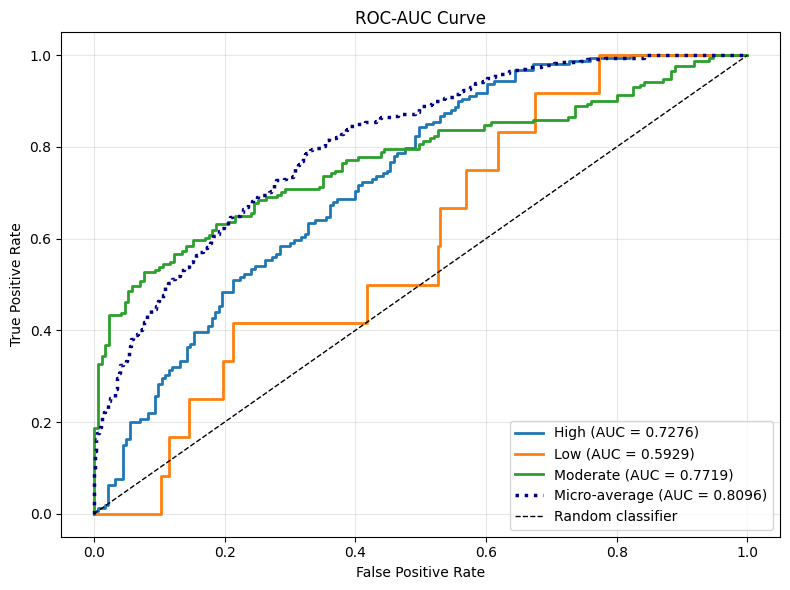

In [52]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

raw_pred = model.predict(X_test, verbose=0)
if num_classes == 2:
    y_pred = (raw_pred.ravel() >= 0.5).astype(int)
    y_score = raw_pred.ravel()
else:
    y_pred = np.argmax(raw_pred, axis=1)
    y_score = raw_pred

print('\nSample predictions (encoded):', y_pred[:10])
print('Sample true labels (encoded):', y_test[:10])

# ROC-AUC curve(s)
plt.figure(figsize=(8, 6))

if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    print(f'ROC AUC: {roc_auc:.4f}')
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', linewidth=2)
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
    auc_scores = []

    # Per-class one-vs-rest ROC curves
    for i in range(num_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_i = auc(fpr_i, tpr_i)
        auc_scores.append(auc_i)
        class_name = label_encoder.inverse_transform([i])[0]
        plt.plot(fpr_i, tpr_i, linewidth=2, label=f'{class_name} (AUC = {auc_i:.4f})')

    # Macro and micro averages
    macro_auc = float(np.mean(auc_scores))
    micro_fpr, micro_tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    micro_auc = auc(micro_fpr, micro_tpr)

    print(f'Macro-average AUC: {macro_auc:.4f}')
    print(f'Micro-average AUC: {micro_auc:.4f}')

    plt.plot(
        micro_fpr,
        micro_tpr,
        color='navy',
        linestyle=':',
        linewidth=2.5,
        label=f'Micro-average (AUC = {micro_auc:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# Human-readable labels
if num_classes == 2:
    y_pred_labels = label_encoder.inverse_transform(y_pred)
else:
    y_pred_labels = label_encoder.inverse_transform(y_pred)

print('Predicted labels:', y_pred_labels[:10])
print('True labels     :', label_encoder.inverse_transform(y_test[:10]))

Predicted labels: ['Moderate' 'High' 'High' 'Moderate' 'Moderate' 'Moderate' 'Low' 'High'
 'High' 'Low']
True labels     : ['Moderate' 'High' 'High' 'Moderate' 'Moderate' 'Moderate' 'High' 'High'
 'Moderate' 'High']
